Exploratory data analysis is structured curiosity. It helps you understand distributions, discover data problems, generate hypotheses, and decide what deserves formal analysis. It does **not** turn every visual pattern into a causal claim.

## Learning goals

You will move from one-variable distributions to group comparisons and relationships, choose robust summaries, quantify uncertainty with a bootstrap, and write conclusions that separate observation from explanation.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

rng = np.random.default_rng(11)
n = 360
segment = rng.choice(["Starter", "Growth", "Enterprise"], n, p=[.48, .37, .15])
tenure = rng.integers(1, 49, n)
visits = rng.poisson(6 + tenure / 16)
segment_effect = pd.Series(segment).map({"Starter": 0, "Growth": 38, "Enterprise": 105}).to_numpy()
spend = (25 + 6.5 * visits + segment_effect + rng.gamma(2, 14, n)).round(2)
satisfaction = np.clip(5.8 + 0.06 * tenure - 0.012 * spend + rng.normal(0, 1.2, n), 1, 10)
customers = pd.DataFrame({
    "segment": segment, "tenure_months": tenure, "monthly_visits": visits,
    "monthly_spend": spend, "satisfaction": satisfaction
})
customers.head()

,segment,tenure_months,monthly_visits,monthly_spend,satisfaction
0,Starter,11,7,80.08,7.001450
1,Growth,33,8,126.02,8.089709
2,Growth,29,13,154.90,7.177617
3,Starter,20,2,56.23,6.152887
4,Starter,6,10,104.05,6.965725


## Begin with a question map

Our broad question is: **which customers appear most engaged, and what should we investigate next?** Break it into smaller questions:

- What is typical, and what is unusual, for each numeric variable?
- How large and different are the customer segments?
- Which variables move together?
- Are apparent differences large relative to sampling variation?

This map keeps exploration directed without pretending we knew the final hypothesis in advance.

## 1. Understand each variable alone

Use counts for categories and multiple summaries for numeric variables. Means answer a different question from medians when a distribution is skewed.

In [2]:
numeric_summary = customers.describe(percentiles=[.1, .25, .5, .75, .9]).T
display(customers["segment"].value_counts().rename("customers"))
numeric_summary.round(2)

segment
Starter       186
Growth        125
Enterprise     49
Name: customers, dtype: int64

,count,mean,std,min,10%,25%,50%,75%,90%,max
tenure_months,360.0,24.80,13.81,1.00,6.00,13.00,24.50,37.00,44.00,48.00
monthly_visits,360.0,7.47,2.83,1.00,4.00,5.75,7.00,9.00,11.10,15.00
monthly_spend,360.0,129.75,44.07,51.51,80.17,97.04,125.44,155.84,194.05,276.19
satisfaction,360.0,5.75,1.52,1.42,3.69,4.70,5.84,6.80,7.77,9.43


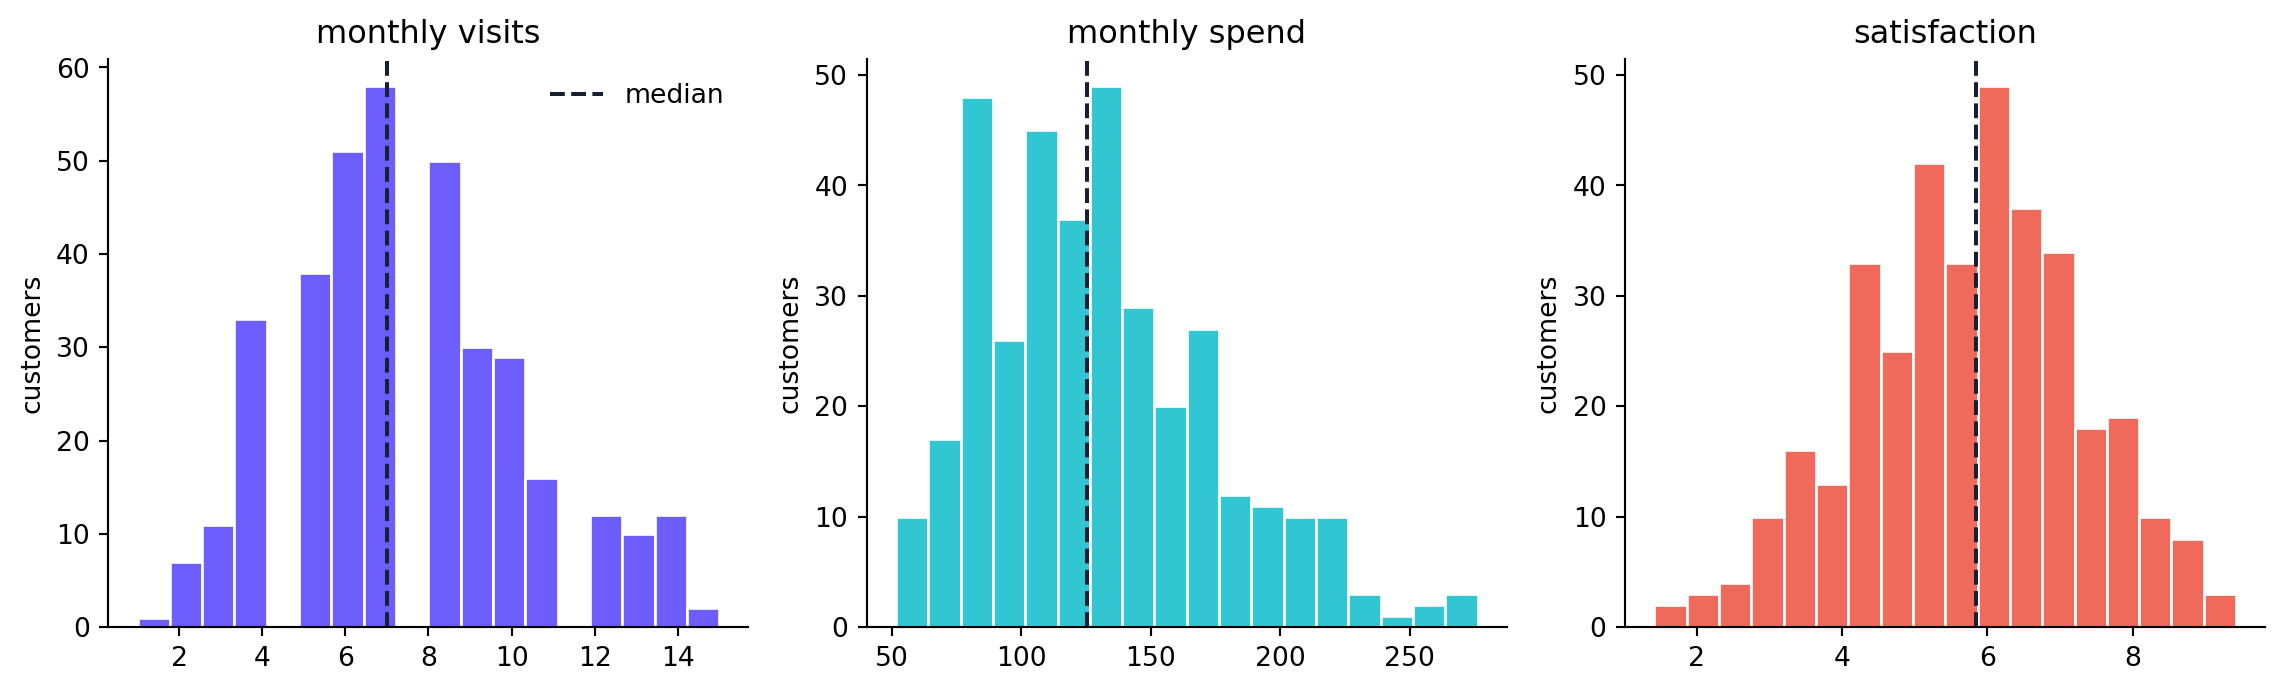

In [3]:
fig, axes = plt.subplots(1, 3, figsize=(12, 3.7))
variables = ["monthly_visits", "monthly_spend", "satisfaction"]
colors = ["#6d5dfc", "#32c5d2", "#ef6a5b"]
for ax, variable, color in zip(axes, variables, colors):
    ax.hist(customers[variable], bins=18, color=color, edgecolor="white")
    ax.axvline(customers[variable].median(), color="#172033", linestyle="--", label="median")
    ax.set(title=variable.replace("_", " "), ylabel="customers")
    ax.spines[["top", "right"]].set_visible(False)
axes[0].legend(frameon=False)
plt.tight_layout()
plt.show()

## 2. Compare groups with size and spread

A group average without the number of observations or within-group variation can mislead. Report all three.

In [4]:
segment_summary = (
    customers.groupby("segment")
    .agg(
        customers=("segment", "size"),
        median_spend=("monthly_spend", "median"),
        mean_visits=("monthly_visits", "mean"),
        mean_satisfaction=("satisfaction", "mean"),
        satisfaction_sd=("satisfaction", "std"),
    )
    .sort_values("median_spend", ascending=False)
)
segment_summary.round(2)

,customers,median_spend,mean_visits,mean_satisfaction,satisfaction_sd
segment,,,,,
Enterprise,49,204.67,7.00,4.83,1.60
Growth,125,136.66,7.63,5.58,1.43
Starter,186,99.64,7.49,6.11,1.44


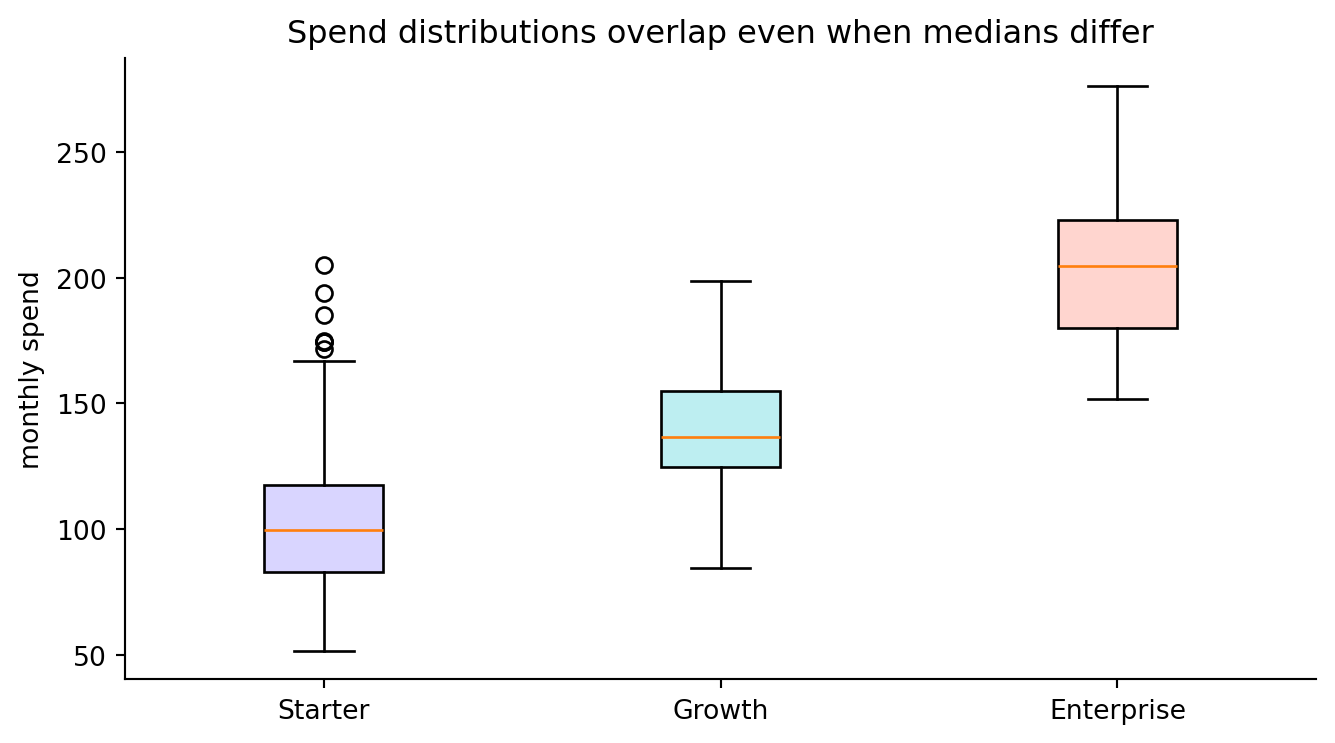

In [5]:
order = ["Starter", "Growth", "Enterprise"]
values = [customers.loc[customers.segment == name, "monthly_spend"] for name in order]
fig, ax = plt.subplots(figsize=(8, 4.2))
box = ax.boxplot(values, tick_labels=order, patch_artist=True, showfliers=True)
for patch, color in zip(box["boxes"], ["#d9d5ff", "#bdeef1", "#ffd5cf"]):
    patch.set_facecolor(color)
ax.set(title="Spend distributions overlap even when medians differ", ylabel="monthly spend")
ax.spines[["top", "right"]].set_visible(False)
plt.show()

## 3. Inspect relationships—and possible confounders

A positive spend–visit relationship is plausible, but segment affects spend too. Color by segment so a pooled trend does not hide group structure.

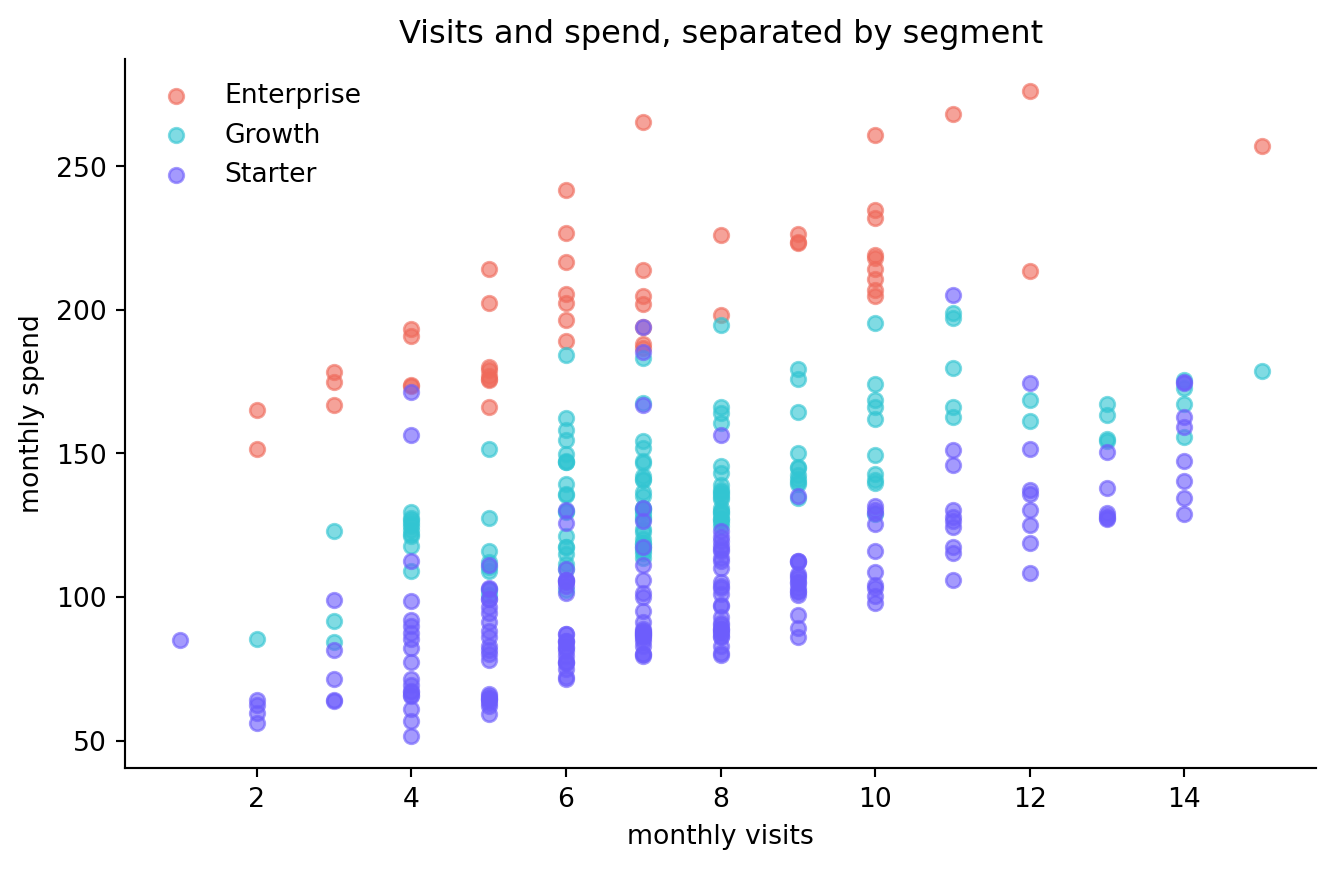

,tenure_months,monthly_visits,monthly_spend,satisfaction
tenure_months,1.00,0.25,0.10,0.53
monthly_visits,0.25,1.00,0.38,0.09
monthly_spend,0.10,0.38,1.00,-0.24
satisfaction,0.53,0.09,-0.24,1.00


In [6]:
palette = {"Starter": "#6d5dfc", "Growth": "#32c5d2", "Enterprise": "#ef6a5b"}
fig, ax = plt.subplots(figsize=(8, 4.8))
for name, group in customers.groupby("segment"):
    ax.scatter(group.monthly_visits, group.monthly_spend, s=30, alpha=.62, label=name, color=palette[name])
ax.set(title="Visits and spend, separated by segment", xlabel="monthly visits", ylabel="monthly spend")
ax.legend(frameon=False)
ax.spines[["top", "right"]].set_visible(False)
plt.show()

customers.select_dtypes("number").corr().round(2)

The correlation table describes linear co-movement in this sample. It does not say that increasing visits will cause spend to rise. Segment, promotions, customer intent, and product availability are all alternative explanations.

## 4. Put uncertainty around a difference

A bootstrap repeatedly resamples observations with replacement. The resulting distribution shows how much a statistic could vary under similar sampling—not every source of real-world uncertainty.

In [7]:
starter = customers.loc[customers.segment == "Starter", "monthly_spend"].to_numpy()
growth = customers.loc[customers.segment == "Growth", "monthly_spend"].to_numpy()

differences = []
for _ in range(2_000):
    starter_sample = rng.choice(starter, size=len(starter), replace=True)
    growth_sample = rng.choice(growth, size=len(growth), replace=True)
    differences.append(np.median(growth_sample) - np.median(starter_sample))

estimate = np.median(growth) - np.median(starter)
lower, upper = np.quantile(differences, [.025, .975])
print(f"Observed median difference: {estimate:.1f}")
print(f"95% bootstrap interval: [{lower:.1f}, {upper:.1f}]")

Observed median difference: 37.0
95% bootstrap interval: [29.6, 46.8]


## Write the conclusion in layers

**Observation:** Enterprise customers have the highest monthly spend distribution, and visits are positively associated with spend inside the sample.

**Inference:** Segment mix explains some of the pooled relationship, so a single overall correlation is incomplete. The bootstrap suggests the Growth–Starter median gap is not just a tiny sample fluctuation in this generated dataset.

**Limitation:** This is observational data. We have not established whether more visits cause more spending, and we have not examined selection into segments.

**Next step:** define an intervention—such as a targeted engagement campaign—and design a controlled test or a stronger quasi-experimental analysis.

## Try it yourself

Investigate satisfaction by tenure. Compare a single overall relationship with relationships inside each segment, then explain whether aggregation changed the story. This completes the core **[Data Science course](index.html)**.